In [2]:
import re
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [3]:
def labels_to_dataframe_verified(file_path, image_dir):
    with open(file_path, 'r') as f:
        content = f.read()

    # Pattern captures the image name and exactly 4 attributes
    pattern = r'(image_\d+\.jpg)\s+(1|0|NA)\s+(1|0|NA)\s+(1|0|NA)\s+(1|0|NA)'
    matches = re.findall(pattern, content)
    
    verified_data = []
    missing_count = 0

    for match in matches:
        img_name = match[0]
        # Construct the full path to check the directory
        full_path = os.path.join(image_dir, img_name)
        
        # Only add to the list if the image actually exists on disk
        if os.path.exists(full_path):
            verified_data.append(match)
        else:
            missing_count += 1

    # Create the DataFrame from only verified rows
    df = pd.DataFrame(verified_data, columns=[
        'image_name', 
        'attribute_1', 
        'attribute_2', 
        'attribute_3', 
        'attribute_4'
    ])

    print(f"Total processed: {len(matches)}")
    print(f"Verified & Added: {len(df)}")
    print(f"Skipped (File not found): {missing_count}")
    
    return df

In [4]:
def load_and_preprocess_image(path, label, mask):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = image / 255.0  # Normalization
    # Combine labels and masks so y_true is a single tensor (batch, 8)
    y_true = tf.concat([label, mask], axis=-1)
    return image, y_true

In [5]:
def get_dataset(text_file_path, img_dir, batch_size=32):
    df = labels_to_dataframe_verified(text_file_path , img_dir)

    df_filled = df.fillna(-1).replace('NA', -1)  # Replace 'NA'
    
    img_paths = [f"{img_dir}/{name}" for name in df_filled.iloc[:, 0]]
    labels = df_filled.iloc[:, 1:5].values.astype(np.float32)
    
    # Create masks: 1 if label is not -1, else 0
    masks = (labels != -1).astype(np.float32)
    # Clean labels: set -1 to 0 
    labels = np.where(labels == -1, 0, labels)
    
    # Create the base dataset
    ds = tf.data.Dataset.from_tensor_slices((img_paths, labels, masks))

    dataset_size = len(img_paths)
    
    ds = ds.shuffle(buffer_size=dataset_size, seed=42)
    train_size = int(0.8 * dataset_size)
    val_size = int(0.1 * dataset_size)
    
    train_ds = ds.take(train_size)
    remaining_ds = ds.skip(train_size)
    val_ds = remaining_ds.take(val_size)
    test_ds = remaining_ds.skip(val_size)
    
    train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return train_ds, val_ds, test_ds

In [6]:
def masked_bce_loss(y_true_combined, y_pred):
    # y_true_combined shape: (batch_size, 8) -> [labels(4), masks(4)]
    y_true = y_true_combined[:, :4]
    mask = y_true_combined[:, 4:]
    
    # Element-wise binary crossentropy (shape: batch, 4)
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    masked_loss = bce * mask
    
    # Avoid division by zero if a whole batch is masked
    denom = tf.reduce_sum(mask) + 1e-7
    return tf.reduce_sum(masked_loss) / denom

In [7]:
def build_model():
    base_model = tf.keras.applications.ResNet50V2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False # Fine-tuning: Freeze base first

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(4, activation='sigmoid') 
    ])
    
    model.compile(optimizer='adam', loss=masked_bce_loss)
    return model

2026-02-26 16:39:51.828724: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-26 16:39:52.385885: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-26 16:39:52.386353: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-26 16:39:52.389522: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-26 16:39:52.390029: I tensorflow/compile

Total processed: 975
Verified & Added: 972
Skipped (File not found): 3
Epoch 1/10


2026-02-26 16:39:59.901772: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2026-02-26 16:40:00.398149: E tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:114] *** WARNING *** You are using ptxas 10.1.243, which is older than 11.1. ptxas before 11.1 is known to miscompile XLA code, leading to incorrect results or invalid-address errors.

2026-02-26 16:40:00.402171: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:231] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 8.6
2026-02-26 16:40:00.402264: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:234] Used ptxas at ptxas
2026-02-26 16:40:00.402389: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:318] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2026-02-26 

 2/25 [=>............................] - ETA: 1s - loss: 0.6474  

2026-02-26 16:40:02.885921: E tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:114] *** WARNING *** You are using ptxas 10.1.243, which is older than 11.1. ptxas before 11.1 is known to miscompile XLA code, leading to incorrect results or invalid-address errors.

2026-02-26 16:40:02.976568: E tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:114] *** WARNING *** You are using ptxas 10.1.243, which is older than 11.1. ptxas before 11.1 is known to miscompile XLA code, leading to incorrect results or invalid-address errors.



25/25 [==============================] - 9s 128ms/step - loss: 0.5563 - val_loss: 0.4176
Epoch 2/10
Epoch 2/10
25/25 [==============================] - 2s 65ms/step - loss: 0.4445 - val_loss: 0.4153
Epoch 3/10
25/25 [==============================] - 2s 65ms/step - loss: 0.4445 - val_loss: 0.4153
Epoch 3/10
25/25 [==============================] - 2s 74ms/step - loss: 0.4136 - val_loss: 0.3707
Epoch 4/10
Epoch 4/10
25/25 [==============================] - 2s 65ms/step - loss: 0.3807 - val_loss: 0.3248
Epoch 5/10
Epoch 5/10
25/25 [==============================] - 2s 64ms/step - loss: 0.3652 - val_loss: 0.3040
Epoch 6/10
25/25 [==============================] - 2s 64ms/step - loss: 0.3652 - val_loss: 0.3040
Epoch 6/10
25/25 [==============================] - 2s 65ms/step - loss: 0.3277 - val_loss: 0.2624
Epoch 7/10
Epoch 7/10
25/25 [==============================] - 2s 74ms/step - loss: 0.2977 - val_loss: 0.2276
Epoch 8/10
Epoch 8/10
25/25 [==============================] - 2s 65ms/step

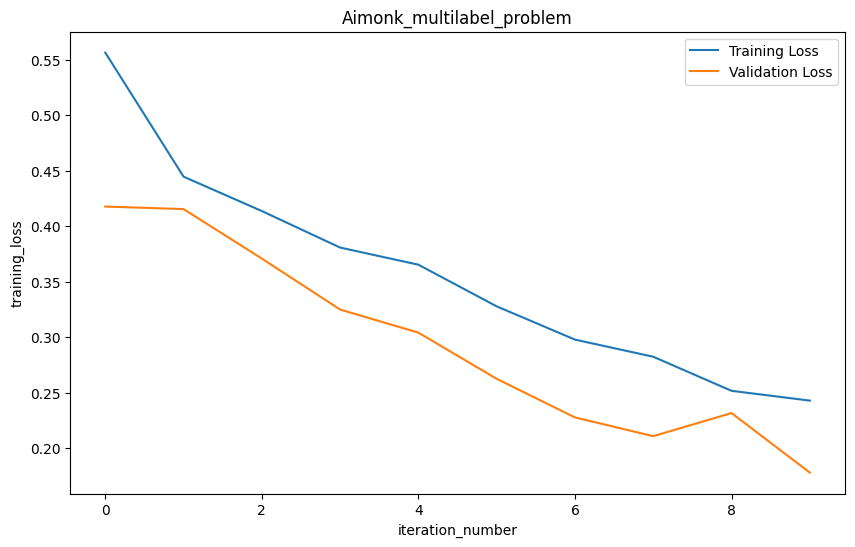

In [8]:
model = build_model()
train_dataset, validation_dataset, test_dataset  = get_dataset("Data/labels.txt", "Data/images/")

history = model.fit(
    train_dataset,
    validation_data=validation_dataset, 
    epochs=10
)

# Deliverable 2: Loss Curve Plot
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss') # The new validation line

plt.ylabel('training_loss')
plt.xlabel('iteration_number') 
plt.title('Aimonk_multilabel_problem')
plt.legend()
plt.savefig('loss_curve.png')
plt.show()

In [9]:
model.save("aimonk_model.h5")

/home/yash/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
